In [ ]:
#data set
a =[0, 0, 1, 1, 0, 0,
   0, 1, 0, 0, 1, 0,
   1, 1, 1, 1, 1, 1,
   1, 0, 0, 0, 0, 1,
   1, 0, 0, 0, 0, 1]
# B
b =[0, 1, 1, 1, 1, 0,
   0, 1, 0, 0, 1, 0,
   0, 1, 1, 1, 1, 0,
   0, 1, 0, 0, 1, 0,
   0, 1, 1, 1, 1, 0]
# C
c =[0, 1, 1, 1, 1, 0,
   0, 1, 0, 0, 0, 0,
   0, 1, 0, 0, 0, 0,
   0, 1, 0, 0, 0, 0,
   0, 1, 1, 1, 1, 0]

# labels
y =[[1, 0, 0],
   [0, 1, 0],
   [0, 0, 1]]

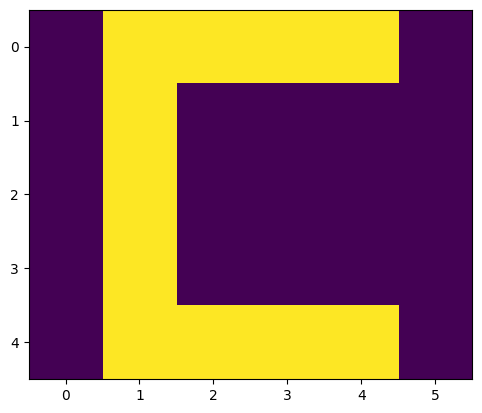

In [13]:
import numpy as np
import matplotlib.pyplot as plt
plt.imshow(np.array(c).reshape(5,6))
plt.show()

In [14]:
x = [np.array(a).reshape(1,30), np.array(b).reshape(1,30), np.array(c).reshape(1,30)]
y = np.array(y)
print(x, "\n\n", y)

[array([[0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
        0, 1, 1, 0, 0, 0, 0, 1]]), array([[0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0,
        1, 0, 0, 1, 1, 1, 1, 0]]), array([[0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
        0, 0, 0, 1, 1, 1, 1, 0]])] 

 [[1 0 0]
 [0 1 0]
 [0 0 1]]


In [15]:
def sigmoid(x):
    return(1/(1+np.exp(-x)))
def f_forward(x, w1, w2):
    z1 = x.dot(w1)
    a1 = sigmoid(z1)
    z2 = a1.dot(w2)
    a2 = sigmoid(z2)
    return(a2)

def generate_wt(x,y):
    li = []
    for i in range(x*y):
        li.append(np.random.randn())
    return(np.array(li).reshape(x ,y))

def loss(out, Y):
    s = (np.square(out-Y))
    s = np.sum(s)/len(Y)
    return(s)

def back_prop(x,y,w1,w2,alpha):
    z1 = x.dot(w1)
    a1 = sigmoid(z1)
    z2 = a1.dot(w2)
    a2 = sigmoid(z2)

    d2 = (a2-y)
    d1 = np.multiply((w2.dot((d2.transpose()))).transpose(), (np.multiply(a1, 1-a1)))
    w1_adj = x.transpose().dot(d1)
    w2_adj = a1.transpose().dot(d2)

    w1 = w1-(alpha*(w1_adj))
    w2 = w2-(alpha*(w2_adj))

    return(w1, w2)

In [16]:
w1 = generate_wt(30, 5)
w2 = generate_wt(5, 3)
print(w1, "\n\n", w2)

[[ 4.43178305e-01  1.10168473e+00  1.35739763e+00  3.31459326e-01
   1.52765954e+00]
 [-5.55001791e-01 -1.13111169e+00  1.08731087e+00  3.35414507e-01
  -1.03371824e-01]
 [-6.51205658e-01 -5.48056686e-01  5.19249893e-01 -1.11097749e+00
   1.02676638e+00]
 [ 2.29090998e+00  1.82696420e+00  1.00642316e+00  3.51032011e-01
  -9.88599246e-01]
 [-7.29475249e-02 -5.77344973e-01 -1.31570974e+00  5.10511180e-01
   1.85191560e+00]
 [-1.31632389e-01  8.16414742e-01  8.11480390e-01  1.84280625e+00
  -1.09076029e+00]
 [-1.06962985e-01 -4.76970262e-01  8.35085435e-01 -6.43030738e-01
   1.26246695e+00]
 [-1.32933594e+00  6.38147819e-01  4.76009667e-01 -1.26533052e+00
   1.07581119e-02]
 [ 4.94837349e-01 -9.99658787e-01 -4.54367190e-01  6.29516797e-01
  -1.38268778e+00]
 [-1.92361010e+00  7.08628951e-01 -3.11552997e-03 -1.24640423e+00
   4.71509371e-01]
 [ 2.32976275e-01 -2.95909707e-02  1.99092396e-01 -1.11732955e+00
   2.64936680e-01]
 [ 4.94471893e-03  1.22702138e-01 -9.62749222e-01 -6.03844049e-01

In [17]:
def train(x, Y, w1, w2, alpha = 0.01, epoch = 10):
	acc =[]
	losss =[]
	for j in range(epoch):
		l =[]
		for i in range(len(x)):
			out = f_forward(x[i], w1, w2)
			l.append((loss(out, Y[i])))
			w1, w2 = back_prop(x[i], y[i], w1, w2, alpha)
		print("epochs:", j + 1, "======== acc:", (1-(sum(l)/len(x)))*100) 
		acc.append((1-(sum(l)/len(x)))*100)
		losss.append(sum(l)/len(x))
	return(acc, losss, w1, w2)

acc, losss, w1, w2 = train(x, y, w1, w2, 0.1, 100)

epochs: 1 ======== acc: 78.66729483906155
epochs: 2 ======== acc: 79.4652146715661
epochs: 3 ======== acc: 80.23168586731802
epochs: 4 ======== acc: 80.96112806260979
epochs: 5 ======== acc: 81.64723535143017
epochs: 6 ======== acc: 82.28509821531011
epochs: 7 ======== acc: 82.87296153147976
epochs: 8 ======== acc: 83.41260009358376
epochs: 9 ======== acc: 83.9082679628782
epochs: 10 ======== acc: 84.36513976890517
epochs: 11 ======== acc: 84.78814237840724
epochs: 12 ======== acc: 85.18144268352697
epochs: 13 ======== acc: 85.54840285083606
epochs: 14 ======== acc: 85.89173694695972
epochs: 15 ======== acc: 86.21369982219956
epochs: 16 ======== acc: 86.51623925584957
epochs: 17 ======== acc: 86.80109826418297
epochs: 18 ======== acc: 87.06987601265708
epochs: 19 ======== acc: 87.32406023736709
epochs: 20 ======== acc: 87.56504227532697
epochs: 21 ======== acc: 87.79412262224955
epochs: 22 ======== acc: 88.01251210883379
epochs: 23 ======== acc: 88.22133170684883
epochs: 24 ======== ac

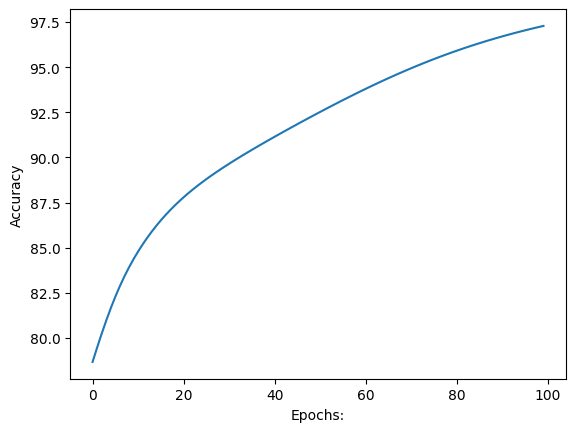

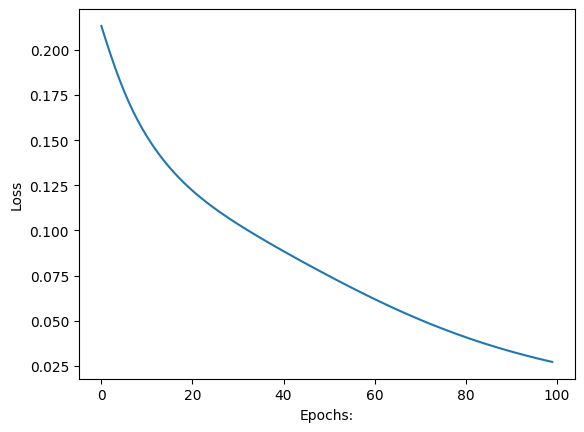

In [18]:
plt.plot(acc)
plt.ylabel('Accuracy')
plt.xlabel("Epochs:")
plt.show()

plt.plot(losss)
plt.ylabel('Loss')
plt.xlabel("Epochs:")
plt.show()

Image is of letter B.


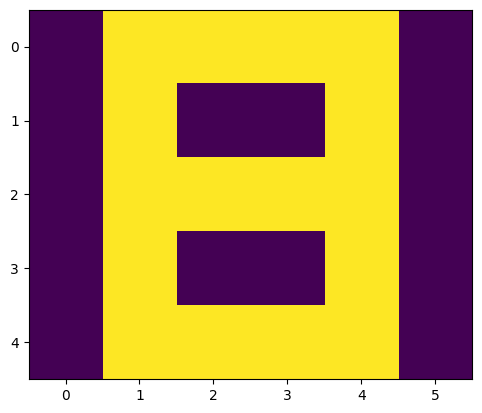

In [19]:
def predict(x, w1, w2):
    Out = f_forward(x, w1, w2)
    maxm = 0
    k = 0
    for i in range(len(Out[0])):
        if(maxm<Out[0][i]):
            maxm = Out[0][i]
            k = i
    if(k == 0):
        print("Image is of letter A.")
    elif(k == 1):
        print("Image is of letter B.")
    else:
        print("Image is of letter C")
    plt.imshow(x.reshape(5, 6))
    plt.show()

predict(x[1], w1, w2)